In [1]:
%load_ext rpy2.ipython

In [25]:
%%R

library(tidyverse)
library(GENOVA)
library(GenomicRanges)
library(GenomicFeatures)
library(TxDb.Mmusculus.UCSC.mm10.ensGene)
library(ChIPseeker)
library(DOSE)

In [26]:
%%R

# Function to process regulatory elements for a given prefix
process_regulatory_elements <- function(prefix) {
  ## For appeared loops ----
  
  # Appeared loops with enhancers within left/right anchor
  ap_enh_left <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_up_', prefix, '_union_1_3.bed'))
  ap_enh_right <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_up_', prefix, '_union_4_6.bed'))
  
  ap_enh_left$annotation <- 'Enhancer'
  ap_enh_right$annotation <- 'Enhancer'
  colnames(ap_enh_left)[1:3] <- c('seqnames', 'start', 'end')
  colnames(ap_enh_right)[1:3] <- c('seqnames', 'start', 'end')
  ap_enh_left$anchor <- 'Left'
  ap_enh_right$anchor <- 'Right'
  
  ap_enh_left <- ap_enh_left[c(1:3,16,17)]
  ap_enh_right <- ap_enh_right[c(1:3,16,17)]
  
  # Appeared loops with promoters within left/right anchor
  ap_left <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/up_', prefix, '_ann_1_3.csv'), header = T, sep='\t')
  ap_right <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/up_', prefix, '_ann_4_6.csv'), header = T, sep='\t')
  
  ap_pro_left <- subset(ap_left, grepl("Promoter", annotation) & !is.na(SYMBOL))
  ap_pro_right <- subset(ap_right, grepl("Promoter", annotation) & !is.na(SYMBOL))
  
  ap_pro_left$anchor <- 'Left'
  ap_pro_right$anchor <- 'Right'
  
  ap_pro_left <- ap_pro_left[c(1:3,6,21)]
  ap_pro_right <- ap_pro_right[c(1:3,6,21)]
  
  app_reg_el <- rbind(ap_enh_left, ap_enh_right, ap_pro_left, ap_pro_right)
  colnames(app_reg_el)[1] <- 'chr'
  
  app_loops <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_', prefix, '_union.bed'))
  app_loops <- app_loops[c(1:6)]
  colnames(app_loops) <- c("chr1", "start1", "end1", "chr2", "start2", "end2")
  
  app_reg_el$annotation <- gsub(".*Promoter.*", "Promoter", app_reg_el$annotation)
  app_pro <- subset(app_reg_el, annotation == 'Promoter')
  app_enh <- subset(app_reg_el, annotation == 'Enhancer')
  
  left_join_result <- left_join(app_loops, app_pro, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(app_loops, app_pro, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  pro <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  pro <- distinct(pro, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  left_join_result <- left_join(app_loops, app_enh, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(app_loops, app_enh, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  enh <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  enh <- distinct(enh, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  enh <- enh[c(1:6,9,12)]
  pro <- pro[c(1:6,9,12)]
  
  df <- cbind(enh, pro)
  colnames(df)[15:16] <- c('Left2', 'Right2')
  
  df$Combination_Left <- paste(df$Left, df$Left2, sep = " - ")
  df$Combination_Right <- paste(df$Right, df$Right2, sep = " - ")
  
  classify_part <- function(part) {
    if (grepl("Enhancer", part) & grepl("Promoter", part)) {
      return("Enhancer-Promoter")
    }
    else if (part == "0 - 0") {
      return("None")
    }
    else if (grepl("Enhancer", part)) {
      return("Enhancer")
    }
    else if (grepl("Promoter", part)) {
      return("Promoter")
    }
    else {
      return(part)
    }
  }
  
  classify_combination <- function(left_comb, right_comb) {
    left_class <- classify_part(left_comb)
    right_class <- classify_part(right_comb)
    
    return(paste(left_class, right_class, sep = "-"))
  }
  
  df$Classification <- mapply(classify_combination, df$Combination_Left, df$Combination_Right)
  
  groups <- c("None-None", 
              "Enhancer-None", 
              "Enhancer-Enhancer", 
              "Enhancer-Promoter", 
              "Promoter-None", 
              "Promoter-Promoter")
  
  standardize_group <- function(classification) {
    parts <- unlist(strsplit(classification, "-"))
    
    sorted_parts <- sort(parts)
    
    if (sorted_parts[1] == "Enhancer" && sorted_parts[2] == "Promoter") {
      return("Enhancer-Promoter")
    }
    
    if (grepl("Enhancer-Promoter", classification)) {
      return("Enhancer-Promoter")
    }
    
    if (sorted_parts[1] == "None" && sorted_parts[2] == "Promoter") {
      return("Promoter-None")
    }
    
    return(paste(sorted_parts, collapse = "-"))
  }
  
  df$Standardized_Classification <- sapply(df$Classification, standardize_group)
  
  group_counts <- table(factor(df$Standardized_Classification, levels = groups))
  
  app_group_counts_df <- as.data.frame(group_counts)
  
  ## For disappeared loops ----
  
  # Disappeared loops with enhancers within left/right anchor
  dis_enh_left <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_down_', prefix, '_union_1_3.bed'))
  dis_enh_right <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_down_', prefix, '_union_4_6.bed'))
  
  dis_enh_left$annotation <- 'Enhancer'
  dis_enh_right$annotation <- 'Enhancer'
  colnames(dis_enh_left)[1:3] <- c('seqnames', 'start', 'end')
  colnames(dis_enh_right)[1:3] <- c('seqnames', 'start', 'end')
  dis_enh_left$anchor <- 'Left'
  dis_enh_right$anchor <- 'Right'
  
  dis_enh_left <- dis_enh_left[c(1:3,16,17)]
  dis_enh_right <- dis_enh_right[c(1:3,16,17)]
  
  # Disappeared loops with promoters within left/right anchor
  dis_left <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/down_', prefix, '_ann_1_3.csv'), header = T, sep='\t')
  dis_right <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/down_', prefix, '_ann_4_6.csv'), header = T, sep='\t')
  
  dis_pro_left <- subset(dis_left, grepl("Promoter", annotation) & !is.na(SYMBOL))
  dis_pro_right <- subset(dis_right, grepl("Promoter", annotation) & !is.na(SYMBOL))
  
  dis_pro_left$anchor <- 'Left'
  dis_pro_right$anchor <- 'Right'
  
  dis_pro_left <- dis_pro_left[c(1:3,6,21)]
  dis_pro_right <- dis_pro_right[c(1:3,6,21)]
  
  dis_reg_el <- rbind(dis_enh_left, dis_enh_right, dis_pro_left, dis_pro_right)
  colnames(dis_reg_el)[1] <- 'chr'
  
  dis_loops <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_', prefix, '_union.bed'))
  
  colnames(dis_loops) <- c("chr1", "start1", "end1", "chr2", "start2", "end2")
  
  dis_reg_el$annotation <- gsub(".*Promoter.*", "Promoter", dis_reg_el$annotation)
  dis_pro <- subset(dis_reg_el, annotation == 'Promoter')
  dis_enh <- subset(dis_reg_el, annotation == 'Enhancer')
  
  left_join_result <- left_join(dis_loops, dis_pro, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(dis_loops, dis_pro, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  pro <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  pro <- distinct(pro, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  left_join_result <- left_join(dis_loops, dis_enh, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(dis_loops, dis_enh, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  enh <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  enh <- distinct(enh, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  enh <- enh[c(1:6,9,12)]
  pro <- pro[c(1:6,9,12)]
  
  df <- cbind(enh, pro)
  colnames(df)[15:16] <- c('Left2', 'Right2')
  
  df$Combination_Left <- paste(df$Left, df$Left2, sep = " - ")
  df$Combination_Right <- paste(df$Right, df$Right2, sep = " - ")
  
  classify_part <- function(part) {
    if (grepl("Enhancer", part) & grepl("Promoter", part)) {
      return("Enhancer-Promoter")
    }
    else if (part == "0 - 0") {
      return("None")
    }
    else if (grepl("Enhancer", part)) {
      return("Enhancer")
    }
    else if (grepl("Promoter", part)) {
      return("Promoter")
    }
    else {
      return(part)
    }
  }
  
  classify_combination <- function(left_comb, right_comb) {
    left_class <- classify_part(left_comb)
    right_class <- classify_part(right_comb)
    
    return(paste(left_class, right_class, sep = "-"))
  }
  
  df$Classification <- mapply(classify_combination, df$Combination_Left, df$Combination_Right)
  
  groups <- c("None-None", 
              "Enhancer-None", 
              "Enhancer-Enhancer", 
              "Enhancer-Promoter", 
              "Promoter-None", 
              "Promoter-Promoter")
  
  standardize_group <- function(classification) {
    parts <- unlist(strsplit(classification, "-"))
    
    sorted_parts <- sort(parts)
    
    if (sorted_parts[1] == "Enhancer" && sorted_parts[2] == "Promoter") {
      return("Enhancer-Promoter")
    }
    
    if (grepl("Enhancer-Promoter", classification)) {
      return("Enhancer-Promoter")
    }
    
    if (sorted_parts[1] == "None" && sorted_parts[2] == "Promoter") {
      return("Promoter-None")
    }
    
    return(paste(sorted_parts, collapse = "-"))
  }
  
  df$Standardized_Classification <- sapply(df$Classification, standardize_group)
  
  group_counts <- table(factor(df$Standardized_Classification, levels = groups))
  
  dis_group_counts_df <- as.data.frame(group_counts)
  
  group_counts_df <- rbind(app_group_counts_df, dis_group_counts_df)
  group_counts_df$type <- c(rep('Up-folded', times = length(app_group_counts_df$Var1)), 
                            rep('Down-folded', times = length(dis_group_counts_df$Var1)))
  
  group_counts_df$type <- factor(group_counts_df$type, levels=unique(group_counts_df$type))
  
  plot <- ggplot(group_counts_df, aes(fill=type, y=Freq, x=Var1)) + 
          geom_bar(position="dodge", stat="identity", color="black") +
          ylim(0,230) +
          xlab('') + ylab('') +
          scale_fill_brewer(palette="PuBu") +
          theme_classic() +
          theme(axis.text.x = element_text(size=14, angle=45, hjust = 1, colour='black'),
                axis.text.y = element_text(size=15, colour='black'),
                legend.text = element_text(size=14),
                legend.title = element_text(size=15),
                panel.border = element_rect(colour = "black", fill=NA, size=1),
                aspect.ratio = 2/2) +
          labs(fill = "Loops") +
          ggtitle(paste(prefix))
  
  print(plot)
  return(list(data = group_counts_df, plot = plot))
}

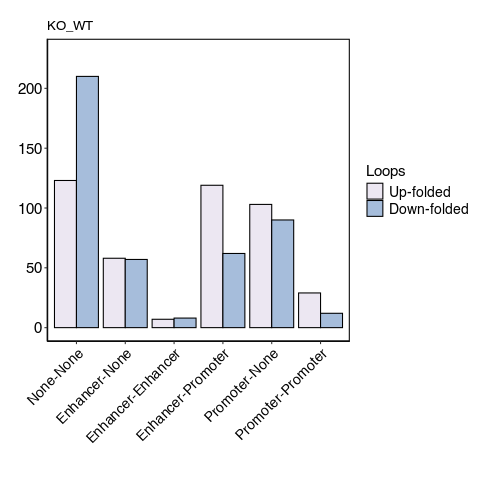

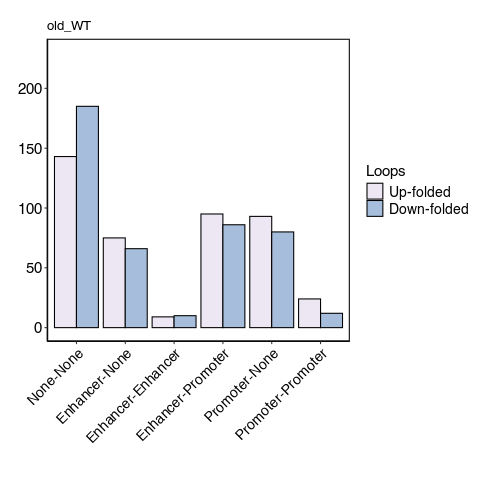

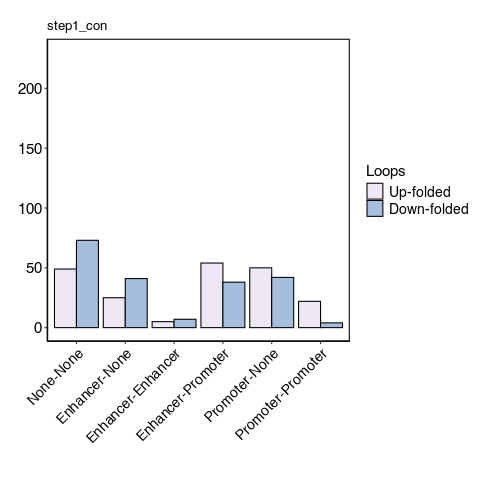

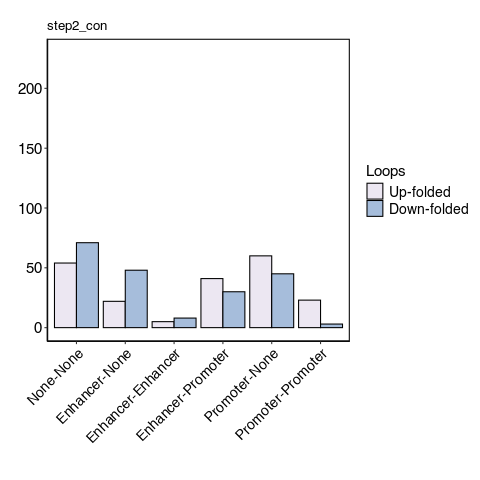

In [27]:
%%R

ko_results <- process_regulatory_elements("KO_WT")
old_results <- process_regulatory_elements("old_WT")
s1_results <- process_regulatory_elements("step1_con")
s2_results <- process_regulatory_elements("step2_con")

In [28]:
%%R

# Function to process regulatory elements for a given prefix
get_regulatory_elements <- function(prefix) {
  ## For appeared loops ----
  
  # Appeared loops with enhancers within left/right anchor
  ap_enh_left <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_up_', prefix, '_union_1_3.bed'))
  ap_enh_right <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_up_', prefix, '_union_4_6.bed'))
  
  ap_enh_left$annotation <- 'Enhancer'
  ap_enh_right$annotation <- 'Enhancer'
  colnames(ap_enh_left)[1:3] <- c('seqnames', 'start', 'end')
  colnames(ap_enh_right)[1:3] <- c('seqnames', 'start', 'end')
  ap_enh_left$anchor <- 'Left'
  ap_enh_right$anchor <- 'Right'
  
  ap_enh_left <- ap_enh_left[c(1:3,16,17)]
  ap_enh_right <- ap_enh_right[c(1:3,16,17)]
  
  # Appeared loops with promoters within left/right anchor
  ap_left <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/up_', prefix, '_ann_1_3.csv'), header = T, sep='\t')
  ap_right <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/up_', prefix, '_ann_4_6.csv'), header = T, sep='\t')
  
  ap_pro_left <- subset(ap_left, grepl("Promoter", annotation) & !is.na(SYMBOL))
  ap_pro_right <- subset(ap_right, grepl("Promoter", annotation) & !is.na(SYMBOL))
  
  ap_pro_left$anchor <- 'Left'
  ap_pro_right$anchor <- 'Right'
  
  ap_pro_left <- ap_pro_left[c(1:3,6,21)]
  ap_pro_right <- ap_pro_right[c(1:3,6,21)]
  
  app_reg_el <- rbind(ap_enh_left, ap_enh_right, ap_pro_left, ap_pro_right)
  colnames(app_reg_el)[1] <- 'chr'
  
  app_loops <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/up_', prefix, '_union.bed'))
  app_loops <- app_loops[c(1:6)]
  colnames(app_loops) <- c("chr1", "start1", "end1", "chr2", "start2", "end2")
  
  app_reg_el$annotation <- gsub(".*Promoter.*", "Promoter", app_reg_el$annotation)
  app_pro <- subset(app_reg_el, annotation == 'Promoter')
  app_enh <- subset(app_reg_el, annotation == 'Enhancer')
  
  left_join_result <- left_join(app_loops, app_pro, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(app_loops, app_pro, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  pro <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  pro <- distinct(pro, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  left_join_result <- left_join(app_loops, app_enh, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(app_loops, app_enh, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  enh <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  enh <- distinct(enh, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  enh <- enh[c(1:6,9,12)]
  pro <- pro[c(1:6,9,12)]
  
  df <- cbind(enh, pro)
  colnames(df)[15:16] <- c('Left2', 'Right2')
  
  df$Combination_Left <- paste(df$Left, df$Left2, sep = " - ")
  df$Combination_Right <- paste(df$Right, df$Right2, sep = " - ")
  
  classify_part <- function(part) {
    if (grepl("Enhancer", part) & grepl("Promoter", part)) {
      return("Enhancer-Promoter")
    }
    else if (part == "0 - 0") {
      return("None")
    }
    else if (grepl("Enhancer", part)) {
      return("Enhancer")
    }
    else if (grepl("Promoter", part)) {
      return("Promoter")
    }
    else {
      return(part)
    }
  }
  
  classify_combination <- function(left_comb, right_comb) {
    left_class <- classify_part(left_comb)
    right_class <- classify_part(right_comb)
    
    return(paste(left_class, right_class, sep = "-"))
  }
  
  df$Classification <- mapply(classify_combination, df$Combination_Left, df$Combination_Right)
  
  groups <- c("None-None", 
              "Enhancer-None", 
              "Enhancer-Enhancer", 
              "Enhancer-Promoter", 
              "Promoter-None", 
              "Promoter-Promoter")
  
  standardize_group <- function(classification) {
    parts <- unlist(strsplit(classification, "-"))
    
    sorted_parts <- sort(parts)
    
    if (sorted_parts[1] == "Enhancer" && sorted_parts[2] == "Promoter") {
      return("Enhancer-Promoter")
    }
    
    if (grepl("Enhancer-Promoter", classification)) {
      return("Enhancer-Promoter")
    }
    
    if (sorted_parts[1] == "None" && sorted_parts[2] == "Promoter") {
      return("Promoter-None")
    }
    
    return(paste(sorted_parts, collapse = "-"))
  }
  
  df$Standardized_Classification <- sapply(df$Classification, standardize_group)
  
  group_counts <- table(factor(df$Standardized_Classification, levels = groups))
  
  app_group_counts_df <- as.data.frame(group_counts)

  df_up <- df
  
  ## For disappeared loops ----
  
  # Disappeared loops with enhancers within left/right anchor
  dis_enh_left <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_down_', prefix, '_union_1_3.bed'))
  dis_enh_right <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_down_', prefix, '_union_4_6.bed'))
  
  dis_enh_left$annotation <- 'Enhancer'
  dis_enh_right$annotation <- 'Enhancer'
  colnames(dis_enh_left)[1:3] <- c('seqnames', 'start', 'end')
  colnames(dis_enh_right)[1:3] <- c('seqnames', 'start', 'end')
  dis_enh_left$anchor <- 'Left'
  dis_enh_right$anchor <- 'Right'
  
  dis_enh_left <- dis_enh_left[c(1:3,16,17)]
  dis_enh_right <- dis_enh_right[c(1:3,16,17)]
  
  # Disappeared loops with promoters within left/right anchor
  dis_left <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/down_', prefix, '_ann_1_3.csv'), header = T, sep='\t')
  dis_right <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/down_', prefix, '_ann_4_6.csv'), header = T, sep='\t')
  
  dis_pro_left <- subset(dis_left, grepl("Promoter", annotation) & !is.na(SYMBOL))
  dis_pro_right <- subset(dis_right, grepl("Promoter", annotation) & !is.na(SYMBOL))
  
  dis_pro_left$anchor <- 'Left'
  dis_pro_right$anchor <- 'Right'
  
  dis_pro_left <- dis_pro_left[c(1:3,6,21)]
  dis_pro_right <- dis_pro_right[c(1:3,6,21)]
  
  dis_reg_el <- rbind(dis_enh_left, dis_enh_right, dis_pro_left, dis_pro_right)
  colnames(dis_reg_el)[1] <- 'chr'
  
  dis_loops <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/down_', prefix, '_union.bed'))
  
  colnames(dis_loops) <- c("chr1", "start1", "end1", "chr2", "start2", "end2")
  
  dis_reg_el$annotation <- gsub(".*Promoter.*", "Promoter", dis_reg_el$annotation)
  dis_pro <- subset(dis_reg_el, annotation == 'Promoter')
  dis_enh <- subset(dis_reg_el, annotation == 'Enhancer')
  
  left_join_result <- left_join(dis_loops, dis_pro, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(dis_loops, dis_pro, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  pro <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  pro <- distinct(pro, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  left_join_result <- left_join(dis_loops, dis_enh, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(dis_loops, dis_enh, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  enh <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  enh <- distinct(enh, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  enh <- enh[c(1:6,9,12)]
  pro <- pro[c(1:6,9,12)]
  
  df <- cbind(enh, pro)
  colnames(df)[15:16] <- c('Left2', 'Right2')
  
  df$Combination_Left <- paste(df$Left, df$Left2, sep = " - ")
  df$Combination_Right <- paste(df$Right, df$Right2, sep = " - ")
  
  classify_part <- function(part) {
    if (grepl("Enhancer", part) & grepl("Promoter", part)) {
      return("Enhancer-Promoter")
    }
    else if (part == "0 - 0") {
      return("None")
    }
    else if (grepl("Enhancer", part)) {
      return("Enhancer")
    }
    else if (grepl("Promoter", part)) {
      return("Promoter")
    }
    else {
      return(part)
    }
  }
  
  classify_combination <- function(left_comb, right_comb) {
    left_class <- classify_part(left_comb)
    right_class <- classify_part(right_comb)
    
    return(paste(left_class, right_class, sep = "-"))
  }
  
  df$Classification <- mapply(classify_combination, df$Combination_Left, df$Combination_Right)
  
  groups <- c("None-None", 
              "Enhancer-None", 
              "Enhancer-Enhancer", 
              "Enhancer-Promoter", 
              "Promoter-None", 
              "Promoter-Promoter")
  
  standardize_group <- function(classification) {
    parts <- unlist(strsplit(classification, "-"))
    
    sorted_parts <- sort(parts)
    
    if (sorted_parts[1] == "Enhancer" && sorted_parts[2] == "Promoter") {
      return("Enhancer-Promoter")
    }
    
    if (grepl("Enhancer-Promoter", classification)) {
      return("Enhancer-Promoter")
    }
    
    if (sorted_parts[1] == "None" && sorted_parts[2] == "Promoter") {
      return("Promoter-None")
    }
    
    return(paste(sorted_parts, collapse = "-"))
  }
  
  df$Standardized_Classification <- sapply(df$Classification, standardize_group)

  df_down <- df
  
  group_counts <- table(factor(df$Standardized_Classification, levels = groups))
  
  dis_group_counts_df <- as.data.frame(group_counts)
  
  group_counts_df <- rbind(app_group_counts_df, dis_group_counts_df)
  group_counts_df$type <- c(rep('Up-folded', times = length(app_group_counts_df$Var1)), 
                            rep('Down-folded', times = length(dis_group_counts_df$Var1)))
  
  group_counts_df$type <- factor(group_counts_df$type, levels=unique(group_counts_df$type))

  
  return(list(up = df_up[c(1:6, 20)], down = df_down[c(1:6, 20)]))
}

In [29]:
%%R

# Function to process regulatory elements for a given prefix
get_unchanged_elements <- function(prefix) {
  ## For appeared loops ----
  
  # Appeared loops with enhancers within left/right anchor
  ap_enh_left <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_mid_', prefix, '_union_1_3.bed'))
  ap_enh_right <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/enh/enh_mid_', prefix, '_union_4_6.bed'))
  
  ap_enh_left$annotation <- 'Enhancer'
  ap_enh_right$annotation <- 'Enhancer'
  colnames(ap_enh_left)[1:3] <- c('seqnames', 'start', 'end')
  colnames(ap_enh_right)[1:3] <- c('seqnames', 'start', 'end')
  ap_enh_left$anchor <- 'Left'
  ap_enh_right$anchor <- 'Right'
  
  ap_enh_left <- ap_enh_left[c(1:3,16,17)]
  ap_enh_right <- ap_enh_right[c(1:3,16,17)]
  
  # Appeared loops with promoters within left/right anchor
  ap_left <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/mid_', prefix, '_ann_1_3.csv'), header = T, sep='\t')
  ap_right <- read.csv(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/pro/mid_', prefix, '_ann_4_6.csv'), header = T, sep='\t')
  
  ap_pro_left <- subset(ap_left, grepl("Promoter", annotation) & !is.na(SYMBOL))
  ap_pro_right <- subset(ap_right, grepl("Promoter", annotation) & !is.na(SYMBOL))
  
  ap_pro_left$anchor <- 'Left'
  ap_pro_right$anchor <- 'Right'
  
  ap_pro_left <- ap_pro_left[c(1:3,6,21)]
  ap_pro_right <- ap_pro_right[c(1:3,6,21)]
  
  app_reg_el <- rbind(ap_enh_left, ap_enh_right, ap_pro_left, ap_pro_right)
  colnames(app_reg_el)[1] <- 'chr'
  
  app_loops <- read.table(paste0('/tank/projects/kashuk_sirt6_hic/loops_10k/diff/mid_', prefix, '_union.bed'))
  app_loops <- app_loops[c(1:6)]
  colnames(app_loops) <- c("chr1", "start1", "end1", "chr2", "start2", "end2")
  
  app_reg_el$annotation <- gsub(".*Promoter.*", "Promoter", app_reg_el$annotation)
  app_pro <- subset(app_reg_el, annotation == 'Promoter')
  app_enh <- subset(app_reg_el, annotation == 'Enhancer')
  
  left_join_result <- left_join(app_loops, app_pro, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(app_loops, app_pro, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  pro <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  pro <- distinct(pro, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  left_join_result <- left_join(app_loops, app_enh, by = c("chr1" = "chr", "start1" = "start", "end1" = "end"), relationship = "many-to-many") %>%
    mutate(Left = ifelse(is.na(annotation), 0, annotation))
  
  right_join_result <- left_join(app_loops, app_enh, by = c("chr2" = "chr", "start2" = "start", "end2" = "end"), relationship = "many-to-many") %>%
    mutate(Right = ifelse(is.na(annotation), 0, annotation))
  
  enh <- merge(left_join_result, right_join_result, by = c("chr1", "start1", "end1", "chr2", "start2", "end2"))
  enh <- distinct(enh, chr1,start1,end1,chr2,start2,end2, .keep_all = TRUE)
  
  enh <- enh[c(1:6,9,12)]
  pro <- pro[c(1:6,9,12)]
  
  df <- cbind(enh, pro)
  colnames(df)[15:16] <- c('Left2', 'Right2')
  
  df$Combination_Left <- paste(df$Left, df$Left2, sep = " - ")
  df$Combination_Right <- paste(df$Right, df$Right2, sep = " - ")
  
  classify_part <- function(part) {
    if (grepl("Enhancer", part) & grepl("Promoter", part)) {
      return("Enhancer-Promoter")
    }
    else if (part == "0 - 0") {
      return("None")
    }
    else if (grepl("Enhancer", part)) {
      return("Enhancer")
    }
    else if (grepl("Promoter", part)) {
      return("Promoter")
    }
    else {
      return(part)
    }
  }
  
  classify_combination <- function(left_comb, right_comb) {
    left_class <- classify_part(left_comb)
    right_class <- classify_part(right_comb)
    
    return(paste(left_class, right_class, sep = "-"))
  }
  
  df$Classification <- mapply(classify_combination, df$Combination_Left, df$Combination_Right)
  
  groups <- c("None-None", 
              "Enhancer-None", 
              "Enhancer-Enhancer", 
              "Enhancer-Promoter", 
              "Promoter-None", 
              "Promoter-Promoter")
  
  standardize_group <- function(classification) {
    parts <- unlist(strsplit(classification, "-"))
    
    sorted_parts <- sort(parts)
    
    if (sorted_parts[1] == "Enhancer" && sorted_parts[2] == "Promoter") {
      return("Enhancer-Promoter")
    }
    
    if (grepl("Enhancer-Promoter", classification)) {
      return("Enhancer-Promoter")
    }
    
    if (sorted_parts[1] == "None" && sorted_parts[2] == "Promoter") {
      return("Promoter-None")
    }
    
    return(paste(sorted_parts, collapse = "-"))
  }
  
  df$Standardized_Classification <- sapply(df$Classification, standardize_group)
  
  group_counts <- table(factor(df$Standardized_Classification, levels = groups))
  
  app_group_counts_df <- as.data.frame(group_counts)

  df_up <- df
  
  return (list(unchanged = df_up[c(1:6, 20)]))
}

In [30]:
%%R
library(dplyr)

ko_wt <- get_regulatory_elements("KO_WT")

save_coordinates <- function(df, prefix){
    anchor_types <- df$up %>% .$Standardized_Classification %>% unique()
    
    dir.create(paste0("DiffLoops/", prefix, "/"), recursive = TRUE, showWarnings = FALSE)
    
    for (anchor in anchor_types){
        df_up <- df$up %>% filter(Standardized_Classification == anchor)
        df_down <- df$down %>% filter(Standardized_Classification == anchor)
    
        df_up_left <- df_up %>% dplyr::select(chr1, start1, end1)
        df_up_right <- df_up %>% dplyr::select(chr2, start2, end2)
        df_down_left <- df_down %>% dplyr::select(chr1, start1, end1)
        df_down_right <- df_down %>% dplyr::select(chr2, start2, end2)

        path <- paste0("DiffLoops/", prefix, "/", gsub("-", "_", anchor))
        
        write.csv(df_up_left, paste0(path, "_up_left_anchors.csv"), row.names = FALSE)
        write.csv(df_down_left, paste0(path, "_down_left_anchors.csv"), row.names = FALSE)
        write.csv(df_up_right, paste0(path, "_up_right_anchors.csv"), row.names = FALSE)
        write.csv(df_down_right, paste0(path, "_down_right_anchors.csv"), row.names = FALSE)
    }
}

save_coordinates(ko_wt, "KO_WT")

In [31]:
%%R

library(GenomicRanges)
library(dplyr)
library(data.table)

# --- 1. Load Data ---

# Load Loop Coordinates
# Assuming your .bed file is tab-separated. 
# Adjust 'header = TRUE/FALSE' depending on if your file has a header row.
#loops_df <- fread("your_loops.bed", header = TRUE) 

# Load MACS2 Peak Files
# MACS2 files usually have no header. We define standard column names.
# We primarily need chr, start, end. We keep 'name' to identify specific peaks.
peak_cols <- c("chr", "start", "end", "name", "score", "strand", 
               "signalValue", "pValue", "qValue", "peak")

# Read Peak File 1
peaks1_df <- fread("/home/dmitriismirnov/Projects/DiffLoops/CTCF/SRX20793681.CTCF_WT1.bed", header = FALSE, col.names = peak_cols)
# Read Peak File 2
peaks2_df <- fread("/home/dmitriismirnov/Projects/DiffLoops/CTCF/SRX20793682.CTCF_WT2.bed", header = FALSE, col.names = peak_cols)

gr_peaks1 <- GRanges(
  seqnames = peaks1_df$chr,
  ranges = IRanges(start = peaks1_df$start, end = peaks1_df$end),
  mcols = data.frame(Peak_ID = peaks1_df$name, Peak_Source = "Replicate1")
)

gr_peaks2 <- GRanges(
  seqnames = peaks2_df$chr,
  ranges = IRanges(start = peaks2_df$start, end = peaks2_df$end),
  mcols = data.frame(Peak_ID = peaks2_df$name, Peak_Source = "Replicate2")
)

gr_all_peaks <- c(gr_peaks1, gr_peaks2)
gr_consensus <- reduce(gr_all_peaks)

In [32]:
%%R

analyze_ctcf_loops <- function(loop_data, consensus_peaks, group_name) {
  # Create GRanges for Anchor 1
  gr_anchor1 <- GRanges(
    seqnames = loop_data$chr1,
    ranges = IRanges(start = loop_data$start1, end = loop_data$end1)
  )
  
  # Create GRanges for Anchor 2
  gr_anchor2 <- GRanges(
    seqnames = loop_data$chr2,
    ranges = IRanges(start = loop_data$start2, end = loop_data$end2)
  )
  
  # Find overlaps for Anchor 1
  hits_1 <- findOverlaps(gr_anchor1, consensus_peaks)
  # Find overlaps for Anchor 2
  hits_2 <- findOverlaps(gr_anchor2, consensus_peaks)
  
  # Get indices of loops that had an overlap
  # queryHits returns the index of the loop in the input dataframe
  loops_hit_anchor1 <- unique(queryHits(hits_1))
  loops_hit_anchor2 <- unique(queryHits(hits_2))
  
  # Combine indices: Loops where EITHER anchor overlaps a CTCF peak
  loops_with_ctcf <- union(loops_hit_anchor1, loops_hit_anchor2)
  
  # Calculate statistics
  total_loops <- nrow(loop_data)
  loops_hit_count <- length(loops_with_ctcf)
  
  # Return a summary row
  return(data.frame(
    Group = group_name,
    Total_Loops = total_loops,
    Loops_With_CTCF = loops_hit_count,
    Percentage = round((loops_hit_count / total_loops) * 100, 2)
  ))
}

In [33]:
%%R

dir.create("DiffLoops/CTCF/Intersection_Results", showWarnings = FALSE)

calculate_overlap <- function(loops_df, ctcf_df, background = FALSE){
    groups <- unique(loops_df$Standardized_Classification)
    summary_list <- list()
    for (grp in groups) {
        subset_data <- loops_df %>% filter(Standardized_Classification == grp)
        results <- analyze_ctcf_loops(subset_data, ctcf_df, grp)

        if (!is.null(background)){
            bg_data <- background %>% filter(Standardized_Classification == grp)
            results_bg <- analyze_ctcf_loops(bg_data, ctcf_df, grp)
            contingency_matrix <- matrix(
                c(results$Loops_With_CTCF, 
                  results$Total_Loops - results$Loops_With_CTCF,
                  results_bg$Loops_With_CTCF, 
                  nrow(bg_data) - results_bg$Loops_With_CTCF),
                  nrow = 2,
                  dimnames = list(c("Target", "Background"), c("Overlap", "NoOverlap"))
            )
            fisher_res <- fisher.test(contingency_matrix, alternative = "two.sided")
            results$p_value = fisher_res$p.value
        }
        summary_list[[grp]] <- results
        
        # Save to CSV
        #write.csv(
        #  results, 
        #  file.path("Intersection_Results", paste0(safe_filename, "_intersected.csv")), 
        #  row.names = FALSE
        #)
    
    }
    return (bind_rows(summary_list))
}

In [34]:
%%R

ko_wt <- get_regulatory_elements("KO_WT")
old_wt <- get_regulatory_elements("old_WT")

ko_wt_unchanged <- get_unchanged_elements("KO_WT")
old_wt_unchanged <- get_unchanged_elements("old_WT")

In [35]:
%%R

ko_wt_up <- calculate_overlap(ko_wt$up, gr_consensus, ko_wt_unchanged$unchanged)
ko_wt_down <- calculate_overlap(ko_wt$down, gr_consensus, ko_wt_unchanged$unchanged)
old_wt_up <- calculate_overlap(old_wt$up, gr_consensus, old_wt_unchanged$unchanged)
old_wt_down <- calculate_overlap(old_wt$down, gr_consensus, old_wt_unchanged$unchanged)

unchanged_ko <- calculate_overlap(ko_wt_unchanged$unchanged, gr_consensus, background = NULL)
unchanged_old <- calculate_overlap(old_wt_unchanged$unchanged, gr_consensus, background = NULL)

In [36]:
%%R

unchanged_ko

              Group Total_Loops Loops_With_CTCF Percentage
1     Promoter-None          95              76      80.00
2         None-None         154             129      83.77
3 Enhancer-Promoter         114             100      87.72
4     Enhancer-None          69              59      85.51
5 Promoter-Promoter          25              22      88.00
6 Enhancer-Enhancer          10               8      80.00


In [37]:
%%R

old_wt_up

              Group Total_Loops Loops_With_CTCF Percentage   p_value
1         None-None         143             103      72.03 0.4929688
2 Enhancer-Promoter          95              88      92.63 0.1167844
3 Enhancer-Enhancer           9               7      77.78 1.0000000
4     Enhancer-None          75              58      77.33 0.4941733
5     Promoter-None          93              82      88.17 0.4853420
6 Promoter-Promoter          24              20      83.33 1.0000000


In [38]:
%%R

old_wt_down

              Group Total_Loops Loops_With_CTCF Percentage   p_value
1         None-None         185             149      80.54 0.3290612
2     Promoter-None          80              67      83.75 1.0000000
3     Enhancer-None          66              51      77.27 0.4818595
4 Enhancer-Promoter          86              75      87.21 0.6384576
5 Promoter-Promoter          12              11      91.67 1.0000000
6 Enhancer-Enhancer          10               7      70.00 0.5054945


In [39]:
%%R

ko_wt_up$Condition <- "KO vs WT_Up"
ko_wt_down$Condition <- "KO vs WT_Down"
old_wt_up$Condition <- "Old vs WT_Up"
old_wt_down$Condition <- "Old vs WT_Down"
unchanged_ko$Condition <- "KO vs WT_Unchanged"
unchanged_old$Condition <- "Old vs WT_Unchanged"

ctcf_summary <- rbind(ko_wt_up, ko_wt_down, old_wt_up, old_wt_down)
ctcf_summary$adj.p <- p.adjust(ctcf_summary$p_value, method = "BH")
#write.csv(ctcf_summary, "CTCF_at_loop_anchors_table.csv")

In [40]:
%%R

groups <- ctcf_summary %>% group_by(Group) %>% summarize(Mean = mean(Percentage)) %>% arrange(desc(Mean)) %>% .$Group
ctcf_summary$Group <- factor(ctcf_summary$Group, levels = rev(groups))
ctcf_summary <- ctcf_summary %>% separate(col = Condition, 
           into = c("Comparison", "Direction"), 
           sep = "_")

In [41]:
%%R
unchanged_ko$Group <- factor(unchanged_ko$Group, levels = rev(groups))
unchanged_old$Group <- factor(unchanged_old$Group, levels = rev(groups))

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: Removed 18 rows containing missing values or values outside the scale range
(`geom_col()`). 
  


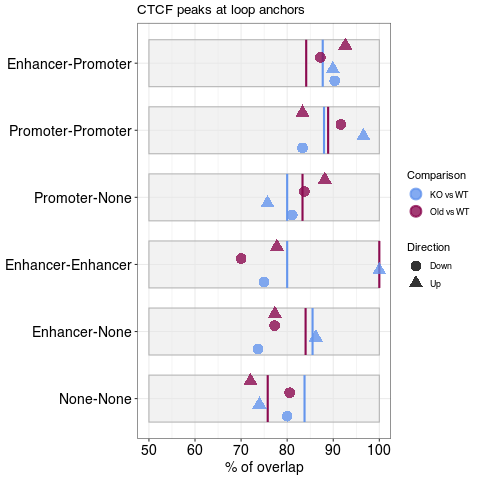

In [42]:
%%R

group_means <- ctcf_summary %>%
  group_by(Group) %>%
  summarise(Mean_Percentage = mean(Percentage))

ggplot(ctcf_summary, aes(x = Percentage, y = Group))+
    geom_col(aes(x = 50, group = Group),           
             fill = "grey90",          
             color = "grey70",         
             orientation = "y",       
             width = 0.7,              
             alpha = 0.5) +  
    #geom_segment(data = group_means, 
    #             aes(x = Mean_Percentage, xend = Mean_Percentage, 
    #                 y = as.numeric(Group) - 0.35, 
    #                 yend = as.numeric(Group) + 0.35),
    #             color = "black", 
    #             linewidth = 1) +
    geom_segment(data = unchanged_ko, 
                 aes(x = Percentage, xend = Percentage, 
                     y = as.numeric(Group) - 0.35, 
                     yend = as.numeric(Group) + 0.35),
                 color = 'cornflowerblue', 
                 linewidth = 1) +
    geom_segment(data = unchanged_old, 
                 aes(x = Percentage, xend = Percentage, 
                     y = as.numeric(Group) - 0.35, 
                     yend = as.numeric(Group) + 0.35),
                 color = 'deeppink4', 
                 linewidth = 1) +
    geom_point(aes(color = Comparison, shape = Direction), stroke = 1.5, alpha = 0.8, size = 4, position = position_dodge(width = 0.7)) + 
    scale_color_manual(values = c('cornflowerblue', 'deeppink4'))+
    scale_x_continuous(limits = c(50, 100))+
    ylab(NULL) + xlab("% of overlap") + ggtitle("CTCF peaks at loop anchors") + theme_dose() 

#ggsave("CTCF_in_loops.png",  width = 6.5, height = 6, dpi = 300)